# Notebook 03 — Fine-Tune RoBERTa-base Classifier

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  
**Week:** 2–3 of 13  

**Goal of this notebook:**
- Load the preprocessed train and validation sets
- Tokenise text using RoBERTa tokeniser
- Fine-tune `roberta-base` as a binary classifier (human=0 vs AI=1)
- Track training with Weights & Biases (wandb)
- Save the best model checkpoint
- Plot and save training curves (loss and accuracy per epoch)

**Expected runtime:** ~1.5–2 hours on a 6GB VRAM GPU  
**Reference:** Liu et al. (2019) RoBERTa. arXiv:1907.11692

## 1. Imports and Paths

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

import torch
from torch.utils.data import Dataset

# HuggingFace libraries
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support
)

# Experiment tracking
import wandb

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR    = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_PROCESSED  = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models', 'checkpoints')
RESULTS_FIGS    = os.path.join(PROJECT_ROOT, 'results', 'figures')
RESULTS_METRICS = os.path.join(PROJECT_ROOT, 'results', 'metrics')
LOGS_DIR        = os.path.join(PROJECT_ROOT, 'logs')

for path in [MODELS_DIR, RESULTS_FIGS, RESULTS_METRICS, LOGS_DIR]:
    os.makedirs(path, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────────────
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

print('Libraries loaded.')
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Libraries loaded.
PyTorch version : 2.2.2+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM            : 6.4 GB


## 2. Weights & Biases Setup

wandb logs all training metrics so you can view live training curves in your browser.

> **First time only:** This cell will prompt you to log in to wandb.  
> Go to [https://wandb.ai](https://wandb.ai) → create a free account → copy your API key when prompted.
>
> **SCREENSHOT REMINDER:** After training starts, go to wandb.ai and take a screenshot of the dashboard.  
> Save as: `screenshots/06_wandb_training_dashboard.png`

In [2]:
# Initialise wandb — this will prompt for API key on first run
wandb.login()

# Project name on wandb dashboard
WANDB_PROJECT = 'msc-ai-detection'
WANDB_RUN_NAME = 'roberta-base-hc3-v1'

print(f'wandb project : {WANDB_PROJECT}')
print(f'wandb run     : {WANDB_RUN_NAME}')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Abdul\_netrc.
wandb: Currently logged in as: ahm11129 (ahm11129-university-of-the-west-of-scotland) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb project : msc-ai-detection
wandb run     : roberta-base-hc3-v1


## 3. Hyperparameters

All hyperparameters are defined here in one place — makes it easy to report them in the dissertation.

> **DISSERTATION NOTE:** These values go into **Table 3** in Chapter 3 (Methodology) — Model Hyperparameters.

In [3]:
# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME  = 'roberta-base'  # pretrained model from HuggingFace Hub
NUM_LABELS  = 2               # binary: 0=human, 1=ai
MAX_LENGTH  = 512             # RoBERTa maximum token length

# ── Training ──────────────────────────────────────────────────────────────────
# Batch size 8 + gradient accumulation 4 = effective batch size of 32
# Keeps memory within 6GB VRAM
BATCH_SIZE          = 8
GRAD_ACCUM_STEPS    = 4       # effective batch size = BATCH_SIZE * GRAD_ACCUM_STEPS
NUM_EPOCHS          = 3       # 3 epochs is standard for BERT-family fine-tuning
LEARNING_RATE       = 2e-5    # standard for transformer fine-tuning
WEIGHT_DECAY        = 0.01    # L2 regularisation
WARMUP_RATIO        = 0.1     # 10% of steps used for learning rate warmup
FP16                = torch.cuda.is_available()  # use mixed precision if GPU available

# Print hyperparameter table
print('=== HYPERPARAMETERS (Table 3 for dissertation) ===')
print(f'  Model                 : {MODEL_NAME}')
print(f'  Max token length      : {MAX_LENGTH}')
print(f'  Batch size (device)   : {BATCH_SIZE}')
print(f'  Gradient accumulation : {GRAD_ACCUM_STEPS}')
print(f'  Effective batch size  : {BATCH_SIZE * GRAD_ACCUM_STEPS}')
print(f'  Epochs                : {NUM_EPOCHS}')
print(f'  Learning rate         : {LEARNING_RATE}')
print(f'  Weight decay          : {WEIGHT_DECAY}')
print(f'  Warmup ratio          : {WARMUP_RATIO}')
print(f'  Mixed precision (fp16): {FP16}')
print(f'  Random seed           : {RANDOM_SEED}')

=== HYPERPARAMETERS (Table 3 for dissertation) ===
  Model                 : roberta-base
  Max token length      : 512
  Batch size (device)   : 8
  Gradient accumulation : 4
  Effective batch size  : 32
  Epochs                : 3
  Learning rate         : 2e-05
  Weight decay          : 0.01
  Warmup ratio          : 0.1
  Mixed precision (fp16): True
  Random seed           : 42


## 4. Load Data

In [4]:
# Load the preprocessed CSVs produced by Notebook 02
train_df = pd.read_csv(os.path.join(DATA_PROCESSED, 'train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_PROCESSED, 'val.csv'))

print(f'Train samples : {len(train_df):,}  |  Human: {(train_df["label"]==0).sum():,}  AI: {(train_df["label"]==1).sum():,}')
print(f'Val samples   : {len(val_df):,}   |  Human: {(val_df["label"]==0).sum():,}   AI: {(val_df["label"]==1).sum():,}')

Train samples : 55,156  |  Human: 36,808  AI: 18,348
Val samples   : 11,819   |  Human: 7,888   AI: 3,931


## 5. Tokenise the Data

RoBERTa uses a Byte-Pair Encoding (BPE) tokeniser. We tokenise the entire dataset once before training — this is faster than tokenising on-the-fly during each batch.

In [5]:
# Load the RoBERTa tokeniser — downloads vocab files on first run (~1MB)
print('Loading RoBERTa tokeniser...')
tokeniser = RobertaTokenizerFast.from_pretrained(MODEL_NAME)
print('Tokeniser loaded.')

def tokenise_batch(texts):
    """Tokenise a list of texts, padding and truncating to MAX_LENGTH."""
    return tokeniser(
        texts,
        max_length=MAX_LENGTH,
        padding='max_length',   # pad all sequences to MAX_LENGTH
        truncation=True,        # truncate sequences longer than MAX_LENGTH
        return_tensors='pt'     # return PyTorch tensors
    )

# Test tokeniser on one example
example = train_df['text'].iloc[0]
tokens  = tokeniser(example, max_length=MAX_LENGTH, truncation=True)
print(f'\nExample text (first 100 chars): {example[:100]}...')
print(f'Token count: {len(tokens["input_ids"])}')

Loading RoBERTa tokeniser...
Tokeniser loaded.

Example text (first 100 chars): It looks like a coin toss. What you have isn't bad at all. If you have enough free time with your $5...
Token count: 87


## 6. PyTorch Dataset Class

HuggingFace Trainer needs a PyTorch Dataset object. We create a simple wrapper class.

In [6]:
class TextClassificationDataset(Dataset):
    """
    PyTorch Dataset wrapping our CSV data.
    Tokenises text on initialisation and stores input_ids,
    attention_mask, and labels as tensors.
    """
    def __init__(self, dataframe, tokeniser, max_length):
        self.labels = dataframe['label'].tolist()
        # Tokenise all texts at once
        self.encodings = tokeniser(
            dataframe['text'].tolist(),
            max_length=max_length,
            padding='max_length',
            truncation=True
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Return a dict of tensors for one sample
        return {
            'input_ids':      torch.tensor(self.encodings['input_ids'][idx],      dtype=torch.long),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx], dtype=torch.long),
            'labels':         torch.tensor(self.labels[idx],                      dtype=torch.long)
        }


print('Building training dataset (tokenising ~30 seconds)...')
train_dataset = TextClassificationDataset(train_df, tokeniser, MAX_LENGTH)
print(f'Train dataset: {len(train_dataset):,} samples')

print('Building validation dataset...')
val_dataset = TextClassificationDataset(val_df, tokeniser, MAX_LENGTH)
print(f'Val dataset  : {len(val_dataset):,} samples')

Building training dataset (tokenising ~30 seconds)...
Train dataset: 55,156 samples
Building validation dataset...
Val dataset  : 11,819 samples


## 7. Load RoBERTa Model

We load `roberta-base` with a classification head on top (a linear layer mapping hidden states → 2 logits).

In [7]:
print('Loading roberta-base model (~500MB download on first run)...')
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model loaded: {MODEL_NAME}')
print(f'Trainable parameters: {n_params:,}  ({n_params/1e6:.1f}M)')

Loading roberta-base model (~500MB download on first run)...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: roberta-base
Trainable parameters: 124,647,170  (124.6M)


## 8. Define Compute Metrics Function

This function is called at the end of every validation epoch by the Trainer.  
It computes Accuracy, Precision, Recall, and F1 — our four key metrics.

In [8]:
def compute_metrics(eval_pred):
    """
    Computes Accuracy, Precision, Recall, and F1 from model predictions.
    Called automatically by HuggingFace Trainer after each eval epoch.
    """
    logits, labels = eval_pred
    # Convert logits to predicted class (argmax)
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions,
        average='binary',   # binary classification
        pos_label=1         # AI-generated is the positive class
    )

    return {
        'accuracy':  round(accuracy, 4),
        'precision': round(precision, 4),
        'recall':    round(recall, 4),
        'f1':        round(f1, 4)
    }

print('compute_metrics function defined.')

compute_metrics function defined.


## 9. Training Arguments

These control how the Trainer runs: batch size, logging, evaluation frequency, and checkpoint saving.

In [9]:
CHECKPOINT_DIR = os.path.join(MODELS_DIR, 'roberta-hc3')

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,              # where to save checkpoints
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,  # can use larger batch for eval (no gradients)
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    fp16=FP16,                              # mixed precision for 6GB VRAM
    evaluation_strategy='epoch',            # evaluate at end of every epoch
    save_strategy='epoch',                  # save checkpoint at end of every epoch
    load_best_model_at_end=True,            # automatically restore best checkpoint
    metric_for_best_model='f1',             # use F1 to pick the best checkpoint
    greater_is_better=True,
    logging_dir=LOGS_DIR,
    logging_steps=50,                       # log every 50 steps
    report_to='wandb',                      # send metrics to wandb
    run_name=WANDB_RUN_NAME,
    seed=RANDOM_SEED,
    dataloader_num_workers=0,               # 0 is safest on Windows
    save_total_limit=2,                     # only keep last 2 checkpoints (saves disk space)
)

print('TrainingArguments configured.')
print(f'Checkpoints will be saved to: {CHECKPOINT_DIR}')

TrainingArguments configured.
Checkpoints will be saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\models\checkpoints\roberta-hc3


## 10. Train the Model

> **Expected time:** ~1.5–2 hours for 3 epochs on a 6GB VRAM GPU  
> Watch the loss go down and F1 go up after each epoch.
>
> **SCREENSHOT REMINDER:** While training is running, go to [https://wandb.ai](https://wandb.ai), open your project, and take a screenshot of the live training curves.  
> Save as: `screenshots/06_wandb_training_dashboard.png`
>
> **SCREENSHOT REMINDER:** After all 3 epochs finish, take a screenshot of the final epoch output in the notebook.  
> Save as: `screenshots/07_training_complete_output.png`

In [10]:
# Initialise the HuggingFace Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # stop if no improvement for 2 epochs
)

print('Starting training...')
print(f'Effective batch size : {BATCH_SIZE * GRAD_ACCUM_STEPS}')
print(f'Total epochs         : {NUM_EPOCHS}')
print(f'This will take approximately 1.5–2 hours.\n')

# Train — this is the main training loop
train_result = trainer.train()

print('\n=== Training Complete ===')
print(f'Total training time : {train_result.metrics["train_runtime"]:.0f} seconds')
print(f'Samples per second  : {train_result.metrics["train_samples_per_second"]:.2f}')

Starting training...
Effective batch size : 32
Total epochs         : 3
This will take approximately 1.5–2 hours.



wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


  0%|          | 0/5169 [00:00<?, ?it/s]

{'loss': 0.6535, 'grad_norm': 1.373674750328064, 'learning_rate': 1.9342359767891684e-06, 'epoch': 0.03}
{'loss': 0.4826, 'grad_norm': 3.42826771736145, 'learning_rate': 3.868471953578337e-06, 'epoch': 0.06}
{'loss': 0.1481, 'grad_norm': 5.926441192626953, 'learning_rate': 5.7640232108317215e-06, 'epoch': 0.09}
{'loss': 0.0552, 'grad_norm': 0.8974219560623169, 'learning_rate': 7.659574468085107e-06, 'epoch': 0.12}
{'loss': 0.0247, 'grad_norm': 8.630309104919434, 'learning_rate': 9.555125725338492e-06, 'epoch': 0.15}
{'loss': 0.0305, 'grad_norm': 23.124496459960938, 'learning_rate': 1.1450676982591878e-05, 'epoch': 0.17}
{'loss': 0.0258, 'grad_norm': 0.03628314658999443, 'learning_rate': 1.3384912959381045e-05, 'epoch': 0.2}
{'loss': 0.0212, 'grad_norm': 0.016541840508580208, 'learning_rate': 1.5319148936170214e-05, 'epoch': 0.23}
{'loss': 0.0292, 'grad_norm': 0.06415592133998871, 'learning_rate': 1.7253384912959384e-05, 'epoch': 0.26}
{'loss': 0.0278, 'grad_norm': 0.1189006119966507, '

  0%|          | 0/739 [00:00<?, ?it/s]

{'eval_loss': 0.04887528344988823, 'eval_accuracy': 0.9936, 'eval_precision': 0.9813, 'eval_recall': 0.9997, 'eval_f1': 0.9904, 'eval_runtime': 1330.9942, 'eval_samples_per_second': 8.88, 'eval_steps_per_second': 0.555, 'epoch': 1.0}
{'loss': 0.0004, 'grad_norm': 0.0007455801242031157, 'learning_rate': 1.4716251074806536e-05, 'epoch': 1.02}
{'loss': 0.0003, 'grad_norm': 0.000510280835442245, 'learning_rate': 1.450128976784179e-05, 'epoch': 1.04}
{'loss': 0.0, 'grad_norm': 0.012439948506653309, 'learning_rate': 1.4286328460877044e-05, 'epoch': 1.07}
{'loss': 0.0103, 'grad_norm': 0.0007596317445859313, 'learning_rate': 1.4071367153912297e-05, 'epoch': 1.1}
{'loss': 0.0062, 'grad_norm': 0.00360037456266582, 'learning_rate': 1.3856405846947551e-05, 'epoch': 1.13}
{'loss': 0.0001, 'grad_norm': 0.0010163215920329094, 'learning_rate': 1.3641444539982804e-05, 'epoch': 1.16}
{'loss': 0.0068, 'grad_norm': 0.19347961246967316, 'learning_rate': 1.3426483233018057e-05, 'epoch': 1.19}
{'loss': 0.003

  0%|          | 0/739 [00:00<?, ?it/s]

{'eval_loss': 0.030449124053120613, 'eval_accuracy': 0.996, 'eval_precision': 0.9887, 'eval_recall': 0.9995, 'eval_f1': 0.9941, 'eval_runtime': 1338.9924, 'eval_samples_per_second': 8.827, 'eval_steps_per_second': 0.552, 'epoch': 2.0}
{'loss': 0.0006, 'grad_norm': 0.0006372336065396667, 'learning_rate': 7.411865864144454e-06, 'epoch': 2.0}
{'loss': 0.0, 'grad_norm': 0.0007543559186160564, 'learning_rate': 7.196904557179708e-06, 'epoch': 2.03}
{'loss': 0.0, 'grad_norm': 0.0005454387282952666, 'learning_rate': 6.981943250214962e-06, 'epoch': 2.06}
{'loss': 0.0, 'grad_norm': 0.0005914000794291496, 'learning_rate': 6.766981943250216e-06, 'epoch': 2.09}
{'loss': 0.0051, 'grad_norm': 0.0005360093782655895, 'learning_rate': 6.552020636285469e-06, 'epoch': 2.12}
{'loss': 0.0, 'grad_norm': 0.0012412674259394407, 'learning_rate': 6.337059329320723e-06, 'epoch': 2.15}
{'loss': 0.0, 'grad_norm': 0.0007799649611115456, 'learning_rate': 6.122098022355977e-06, 'epoch': 2.18}
{'loss': 0.0046, 'grad_no

  0%|          | 0/739 [00:00<?, ?it/s]

{'eval_loss': 0.03144490718841553, 'eval_accuracy': 0.9959, 'eval_precision': 0.9879, 'eval_recall': 0.9997, 'eval_f1': 0.9938, 'eval_runtime': 1329.6192, 'eval_samples_per_second': 8.889, 'eval_steps_per_second': 0.556, 'epoch': 3.0}
{'train_runtime': 18184.3128, 'train_samples_per_second': 9.099, 'train_steps_per_second': 0.284, 'train_loss': 0.018971457118901785, 'epoch': 3.0}

=== Training Complete ===
Total training time : 18184 seconds
Samples per second  : 9.10


## 11. Save the Best Model

In [11]:
# Save the best model and tokeniser together so Notebook 04 can load them
BEST_MODEL_DIR = os.path.join(MODELS_DIR, 'roberta-hc3-best')
trainer.save_model(BEST_MODEL_DIR)
tokeniser.save_pretrained(BEST_MODEL_DIR)

print(f'Best model saved to: {BEST_MODEL_DIR}')
print('Files saved:', os.listdir(BEST_MODEL_DIR))

Best model saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\models\checkpoints\roberta-hc3-best
Files saved: ['config.json', 'merges.txt', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin', 'vocab.json']


## 12. Extract and Save Training History

We pull the per-epoch metrics from the Trainer log history to plot learning curves.

In [12]:
# Extract per-epoch evaluation metrics from Trainer log history
history = trainer.state.log_history

# Separate training loss entries from evaluation entries
train_logs = [h for h in history if 'loss' in h and 'eval_loss' not in h]
eval_logs  = [h for h in history if 'eval_loss' in h]

# Build a clean per-epoch DataFrame
epochs_data = []
for i, ev in enumerate(eval_logs):
    epochs_data.append({
        'epoch':          ev.get('epoch', i + 1),
        'eval_loss':      ev.get('eval_loss', None),
        'eval_accuracy':  ev.get('eval_accuracy', None),
        'eval_precision': ev.get('eval_precision', None),
        'eval_recall':    ev.get('eval_recall', None),
        'eval_f1':        ev.get('eval_f1', None),
    })

history_df = pd.DataFrame(epochs_data)

# Also get training loss per step
step_df = pd.DataFrame([
    {'step': h['step'], 'train_loss': h['loss']}
    for h in train_logs if 'loss' in h
])

# Save both
history_path = os.path.join(RESULTS_METRICS, 'training_history.csv')
history_df.to_csv(history_path, index=False)

step_path = os.path.join(RESULTS_METRICS, 'training_step_loss.csv')
step_df.to_csv(step_path, index=False)

print('Training history:')
print(history_df.to_string(index=False))

Training history:
   epoch  eval_loss  eval_accuracy  eval_precision  eval_recall  eval_f1
0.999565   0.048875         0.9936          0.9813       0.9997   0.9904
1.999710   0.030449         0.9960          0.9887       0.9995   0.9941
2.998695   0.031445         0.9959          0.9879       0.9997   0.9938


## 13. Plot Training Curves

> **DISSERTATION NOTE:** These plots become **Figures 5 and 6** in Chapter 5 (Results and Evaluation).
>
> **SCREENSHOT REMINDER:** After the plots render, take a screenshot.  
> Save as: `screenshots/08_training_curves.png`

Figure saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig05_training_curves.png


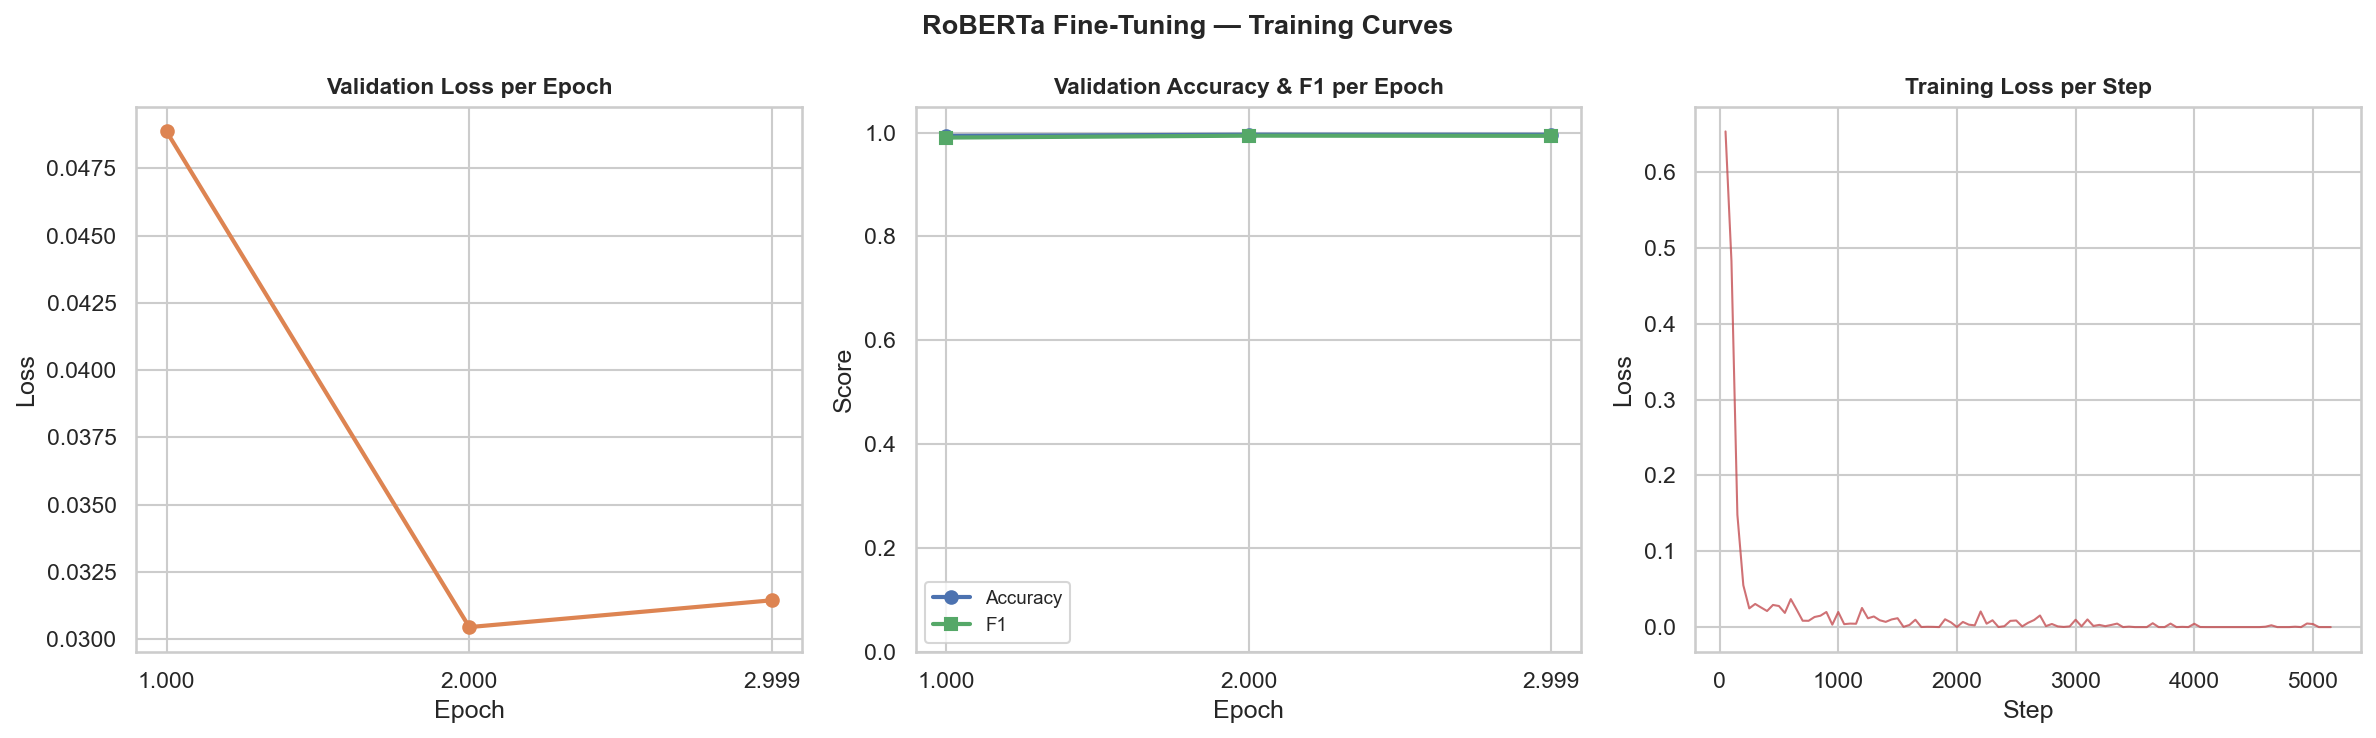

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RoBERTa Fine-Tuning — Training Curves', fontsize=13, fontweight='bold')

epochs = history_df['epoch'].tolist()

# Plot 1 — Validation loss per epoch
axes[0].plot(epochs, history_df['eval_loss'], marker='o', color='#DD8452', linewidth=2)
axes[0].set_title('Validation Loss per Epoch', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs)

# Plot 2 — Validation accuracy per epoch
axes[1].plot(epochs, history_df['eval_accuracy'], marker='o', color='#4C72B0', linewidth=2, label='Accuracy')
axes[1].plot(epochs, history_df['eval_f1'],       marker='s', color='#55A868', linewidth=2, label='F1')
axes[1].set_title('Validation Accuracy & F1 per Epoch', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_xticks(epochs)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

# Plot 3 — Training loss per step
axes[2].plot(step_df['step'], step_df['train_loss'], color='#C44E52', linewidth=1, alpha=0.8)
axes[2].set_title('Training Loss per Step', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Loss')

plt.tight_layout()

fig_path = os.path.join(RESULTS_FIGS, 'fig05_training_curves.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure saved: {fig_path}')
plt.show()

## 14. Save Final Training Metrics

In [14]:
# Get best epoch metrics (highest F1)
best_epoch = history_df.loc[history_df['eval_f1'].idxmax()]

final_metrics = {
    'model':            MODEL_NAME,
    'dataset':          'HC3',
    'best_epoch':       int(best_epoch['epoch']),
    'val_accuracy':     float(best_epoch['eval_accuracy']),
    'val_precision':    float(best_epoch['eval_precision']),
    'val_recall':       float(best_epoch['eval_recall']),
    'val_f1':           float(best_epoch['eval_f1']),
    'val_loss':         float(best_epoch['eval_loss']),
    'hyperparameters': {
        'learning_rate':    LEARNING_RATE,
        'batch_size':       BATCH_SIZE,
        'grad_accum':       GRAD_ACCUM_STEPS,
        'effective_batch':  BATCH_SIZE * GRAD_ACCUM_STEPS,
        'epochs':           NUM_EPOCHS,
        'max_length':       MAX_LENGTH,
        'weight_decay':     WEIGHT_DECAY,
        'warmup_ratio':     WARMUP_RATIO,
        'seed':             RANDOM_SEED
    },
    'best_model_dir':   BEST_MODEL_DIR
}

metrics_path = os.path.join(RESULTS_METRICS, 'training_final_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)

print('=== BEST VALIDATION METRICS ===')
print(f'  Epoch     : {final_metrics["best_epoch"]}')
print(f'  Accuracy  : {final_metrics["val_accuracy"]:.4f}')
print(f'  Precision : {final_metrics["val_precision"]:.4f}')
print(f'  Recall    : {final_metrics["val_recall"]:.4f}')
print(f'  F1        : {final_metrics["val_f1"]:.4f}')
print(f'\nSaved to: {metrics_path}')

# Close wandb run cleanly
wandb.finish()

=== BEST VALIDATION METRICS ===
  Epoch     : 1
  Accuracy  : 0.9960
  Precision : 0.9887
  Recall    : 0.9995
  F1        : 0.9941

Saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\training_final_metrics.json


eval/accuracy,▁██
eval/f1,▁█▇
eval/loss,█▁▁
eval/precision,▁█▇
eval/recall,█▁█
eval/runtime,▂█▁
eval/samples_per_second,▇▁█
eval/steps_per_second,▆▁█
train/epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
+3,...


## 15. Notebook Summary

### What was done
1. Loaded train and validation CSVs from `data/processed/`
2. Tokenised all texts with RoBERTa BPE tokeniser
3. Fine-tuned `roberta-base` for 3 epochs with wandb tracking
4. Saved best checkpoint to `models/checkpoints/roberta-hc3-best/`
5. Saved training curves figure (dissertation Figure 5)
6. Saved all metrics to `results/metrics/`

### Files produced
| File | Location | Purpose |
|------|----------|---------|
| `roberta-hc3-best/` | `models/checkpoints/` | Best fine-tuned model |
| `training_history.csv` | `results/metrics/` | Per-epoch val metrics |
| `training_step_loss.csv` | `results/metrics/` | Per-step train loss |
| `training_final_metrics.json` | `results/metrics/` | Best epoch metrics |
| `fig05_training_curves.png` | `results/figures/` | Dissertation Figure 5 |

### Next step
**Notebook 04:** `04_evaluate_original.ipynb` — Run the saved model on the held-out test set, compute final Accuracy/Precision/Recall/F1, plot confusion matrix and ROC curve.